# NB6 — Architecture comparison (proposal §7.1)

The proposal commits to comparing the ResNet-50 baseline against
**EfficientNet-B0/B3** and a **Vision Transformer (ViT-Base)**, with
"performance reported as a mean and interval rather than a single figure, so
that claimed differences between architectures are distinguishable from
run-to-run variance."

That last clause is doing real work here. RQ3 (NB5) established empirically
that on this corpus **seed-to-seed variation exceeds every between-strategy
difference** — ResNet-50 under identical settings scored macro-F1
0.702 / 0.740 / 0.765 across three seeds. Any architecture comparison run at
a single seed on ACNE04 would therefore be reporting noise. This notebook
runs every architecture across the same seeds and reports intervals.

The same split protocol, augmentation, optimiser, schedule, and epoch budget
are used for all four models, so differences are attributable to the
architecture rather than to incidental tuning.

GPU notebook — **Save & Run All**. Runtime ≈ 3.5–4.5 h for 4 × 3 runs.

**Attach input:** `lexuanhieu131297/acne-severity-classification`

In [1]:
import os, glob, re, math, json, time, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
try:
    import timm
except ImportError:
    os.system("pip install timm -q"); import timm
try:
    import cv2
except ImportError:
    os.system("pip install opencv-python-headless -q"); import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

INPUT, WORK = "/kaggle/input", "/kaggle/working"
os.makedirs(WORK, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

# ---- config -------------------------------------------------------------
SMOKE_TEST = False        # True => 1 epoch, 2 architectures, 1 seed (~5 min)

ARCHITECTURES = {
    "resnet50":         dict(timm_name="resnet50", img=224, batch=32),
    "efficientnet_b0":  dict(timm_name="efficientnet_b0", img=224, batch=32),
    "efficientnet_b3":  dict(timm_name="efficientnet_b3", img=300, batch=16),
    "vit_base":         dict(timm_name="vit_base_patch16_224", img=224,
                             batch=16),
}
SEEDS = [0, 1, 2]
EPOCHS = 18
LR = 3e-4
if SMOKE_TEST:
    ARCHITECTURES = {k: ARCHITECTURES[k]
                     for k in ("resnet50", "efficientnet_b0")}
    SEEDS, EPOCHS = [0], 1
    print(">>> SMOKE_TEST ON — not a real run <<<")
RNG = np.random.default_rng(42)

device: cuda


## 1. Data — identical to NB3/NB5 so results are directly comparable

In [2]:
def find_dir(keys):
    best, best_n = None, -1
    for dp, _, _ in os.walk(INPUT):
        if any(k in os.path.basename(dp).lower() for k in keys):
            n = sum(1 for _, _, fs in os.walk(dp)
                    for f in fs if f.lower().endswith(IMG_EXT))
            if n > best_n:
                best, best_n = dp, n
    return best


def acne_label(p):
    m = re.search(r"lev[le]{0,2}\s*([0-3])", p.lower())
    return int(m.group(1)) if m else -1


def skin_mask(bgr):
    y = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb); cr, cb = y[:, :, 1], y[:, :, 2]
    m1 = (cr >= 133) & (cr <= 173) & (cb >= 77) & (cb <= 127)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    return m1 & (((h <= 25) | (h >= 165)) & (s >= 25) & (s <= 230) & (v >= 40))


def ita_method_b(path):
    img = cv2.imread(path)
    if img is None:
        return np.nan
    h, w = img.shape[:2]; s = 512 / max(h, w)
    if s < 1:
        img = cv2.resize(img, (int(w * s), int(h * s)))
    m = skin_mask(img)
    if m.sum() < 200:
        return np.nan
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[:, :, 0] * (100 / 255); a = lab[:, :, 1] - 128.0
    b = lab[:, :, 2] - 128.0
    Ls, as_, bs = L[m], a[m], b[m]
    if len(Ls) < 100:
        return np.nan
    keep = as_ <= np.percentile(as_, 75)
    if keep.sum() >= 50:
        Ls, bs = Ls[keep], bs[keep]
    k2 = Ls >= np.median(Ls)
    Lm, bm = float(np.median(Ls[k2])), float(np.median(bs[k2]))
    return math.degrees(math.atan2(Lm - 50, bm)) if bm != 0 else np.nan


ACNE = find_dir(["acne"]); assert ACNE, "ACNE04 not attached"
paths = [os.path.join(dp, f) for dp, _, fs in os.walk(ACNE)
         for f in fs if f.lower().endswith(IMG_EXT)]

csv = glob.glob(os.path.join(INPUT, "**", "acne04_ita_validated.csv"),
                recursive=True)
if csv:
    print("reusing NB1b ITA table")
    df = pd.read_csv(csv[0])
else:
    print(f"computing Method-B ITA for {len(paths)} images ...")
    df = pd.DataFrame({"path": paths})
    df["ita_B"] = [ita_method_b(p) for p in df["path"]]
df["tone_band"] = df["ita_B"].map(
    lambda v: "unknown" if pd.isna(v) else
    "Light" if v > 41 else "Medium" if v > 19 else "Deep")
if "label" not in df:
    df["label"] = df["path"].map(acne_label)
df = df[df["label"].between(0, 3)].reset_index(drop=True)
classes = sorted(df["label"].unique()); n_cls = len(classes)
GROUPS = ["Light", "Medium"]
df["strata"] = df["label"].astype(str) + "_" + df["tone_band"]
vc = df["strata"].value_counts()
df.loc[df["strata"].isin(vc[vc < 3].index), "strata"] = "rare"
print("\nseverity:\n", df["label"].value_counts().sort_index())
print("\ntone band:\n", df["tone_band"].value_counts())

computing Method-B ITA for 1457 images ...

severity:
 label
0    497
1    637
2    186
3    137
Name: count, dtype: int64

tone band:
 tone_band
Medium    724
Light     538
Deep      195
Name: count, dtype: int64


## 2. One training run for a given architecture and seed

In [3]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]


def make_tfs(img_size):
    train_tf = T.Compose([T.Resize((img_size, img_size)),
                          T.RandomHorizontalFlip(), T.RandomRotation(10),
                          T.ColorJitter(brightness=0.05, contrast=0.05),
                          T.ToTensor(), T.Normalize(MEAN, STD)])
    eval_tf = T.Compose([T.Resize((img_size, img_size)),
                         T.ToTensor(), T.Normalize(MEAN, STD)])
    return train_tf, eval_tf


class DS(Dataset):
    def __init__(self, frame, tf):
        self.p = frame["path"].values; self.y = frame["label"].values
        self.g = frame["tone_band"].values; self.tf = tf
    def __len__(self): return len(self.p)
    def __getitem__(self, i):
        return (self.tf(Image.open(self.p[i]).convert("RGB")),
                int(self.y[i]), self.g[i])


def collate(b):
    x, y, g = zip(*b)
    return torch.stack(x), torch.tensor(y), list(g)


def ece_score(conf, correct, n_bins=10):
    conf = np.asarray(conf); correct = np.asarray(correct, float)
    bins = np.linspace(0, 1, n_bins + 1); e = 0.0; N = len(conf)
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i + 1])
        if m.sum():
            e += (m.sum() / N) * abs(correct[m].mean() - conf[m].mean())
    return e


def run(arch_name, spec, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    tr, te = train_test_split(df, test_size=0.25, random_state=seed,
                              stratify=df["strata"])
    train_tf, eval_tf = make_tfs(spec["img"])
    tr_dl = DataLoader(DS(tr, train_tf), batch_size=spec["batch"], shuffle=True,
                       num_workers=2, pin_memory=True, collate_fn=collate)
    te_dl = DataLoader(DS(te, eval_tf), batch_size=spec["batch"], shuffle=False,
                       num_workers=2, pin_memory=True, collate_fn=collate)

    model = timm.create_model(spec["timm_name"], pretrained=True,
                              num_classes=n_cls).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    # class weighting held constant across architectures (as in the NB3 baseline)
    cnt = tr["label"].value_counts().reindex(classes).fillna(1).values
    w = torch.tensor(cnt.sum() / (n_cls * cnt), dtype=torch.float32,
                     device=DEVICE)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")

    for ep in range(EPOCHS):
        model.train()
        for x, y, g in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()

    model.eval(); rows = []
    with torch.no_grad():
        for x, y, g in te_dl:
            with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                prob = torch.softmax(model(x.to(DEVICE)), 1).float().cpu().numpy()
            pred = prob.argmax(1)
            for j in range(len(g)):
                rows.append(dict(g=g[j], y=int(y[j]), p=int(pred[j]),
                                 conf=float(prob[j].max())))
    r = pd.DataFrame(rows)
    out = dict(arch=arch_name, seed=seed, params_m=n_params,
               acc=accuracy_score(r.y, r.p),
               macro_f1=f1_score(r.y, r.p, average="macro"),
               f1_severe=f1_score(r.y, r.p, average=None, labels=[2],
                                  zero_division=0)[0],
               ece=ece_score(r.conf, r.y == r.p))
    for g in GROUPS:
        s = r[r.g == g]
        out[f"acc_{g}"] = accuracy_score(s.y, s.p) if len(s) else np.nan
    out["acc_gap"] = out["acc_Light"] - out["acc_Medium"]
    return out

## 3. Run every architecture across seeds

In [4]:
results = []
for name, spec in ARCHITECTURES.items():
    for sd in SEEDS:
        t0 = time.time()
        try:
            res = run(name, spec, sd)
        except RuntimeError as e:                 # typically CUDA OOM on ViT
            print(f"!! {name} seed{sd} FAILED: {e}")
            torch.cuda.empty_cache()
            continue
        res["seconds"] = time.time() - t0
        results.append(res)
        print(f"{name:18s} seed{sd}  acc={res['acc']:.4f}  "
              f"macroF1={res['macro_f1']:.4f}  ECE={res['ece']:.4f}  "
              f"({res['seconds']:.0f}s, {res['params_m']:.1f}M params)")
        pd.DataFrame(results).to_csv(
            os.path.join(WORK, "arch_comparison_raw.csv"), index=False)
        torch.cuda.empty_cache()

R = pd.DataFrame(results)
agg = R.groupby("arch").agg(
    params_m=("params_m", "first"),
    acc_mean=("acc", "mean"), acc_std=("acc", "std"),
    f1_mean=("macro_f1", "mean"), f1_std=("macro_f1", "std"),
    severe_mean=("f1_severe", "mean"),
    ece_mean=("ece", "mean"),
    gap_mean=("acc_gap", lambda s: np.mean(np.abs(s))),
    secs=("seconds", "mean"),
).reset_index().sort_values("f1_mean", ascending=False)
agg.to_csv(os.path.join(WORK, "arch_comparison_summary.csv"), index=False)

print("\n=== Architecture comparison (mean +/- sd over seeds) ===\n")
print("| architecture | params (M) | accuracy | macro-F1 | severe F1 | ECE | |tone gap| | min/run |")
print("|---|---|---|---|---|---|---|---|")
for r in agg.itertuples():
    print(f"| {r.arch} | {r.params_m:.1f} | {r.acc_mean:.3f}+/-{(r.acc_std or 0):.3f} | "
          f"{r.f1_mean:.3f}+/-{(r.f1_std or 0):.3f} | {r.severe_mean:.3f} | "
          f"{r.ece_mean:.3f} | {r.gap_mean:.3f} | {r.secs/60:.0f} |")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

resnet50           seed0  acc=0.7178  macroF1=0.7066  ECE=0.1505  (1058s, 23.5M params)
resnet50           seed1  acc=0.7507  macroF1=0.7293  ECE=0.1075  (1055s, 23.5M params)
resnet50           seed2  acc=0.7918  macroF1=0.7580  ECE=0.0650  (968s, 23.5M params)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

efficientnet_b0    seed0  acc=0.6712  macroF1=0.6539  ECE=0.2325  (1049s, 4.0M params)
efficientnet_b0    seed1  acc=0.7507  macroF1=0.7311  ECE=0.1596  (1034s, 4.0M params)
efficientnet_b0    seed2  acc=0.7233  macroF1=0.6845  ECE=0.1791  (1038s, 4.0M params)


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

efficientnet_b3    seed0  acc=0.6904  macroF1=0.6444  ECE=0.1919  (1325s, 10.7M params)
efficientnet_b3    seed1  acc=0.7123  macroF1=0.7004  ECE=0.1872  (1196s, 10.7M params)
efficientnet_b3    seed2  acc=0.7233  macroF1=0.6932  ECE=0.1692  (1188s, 10.7M params)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

vit_base           seed0  acc=0.5836  macroF1=0.5963  ECE=0.1336  (1280s, 85.8M params)
vit_base           seed1  acc=0.6493  macroF1=0.6681  ECE=0.0667  (1274s, 85.8M params)
vit_base           seed2  acc=0.6740  macroF1=0.6541  ECE=0.0542  (1259s, 85.8M params)

=== Architecture comparison (mean +/- sd over seeds) ===

| architecture | params (M) | accuracy | macro-F1 | severe F1 | ECE | |tone gap| | min/run |
|---|---|---|---|---|---|---|---|
| resnet50 | 23.5 | 0.753+/-0.037 | 0.731+/-0.026 | 0.582 | 0.108 | 0.052 | 17 |
| efficientnet_b0 | 4.0 | 0.715+/-0.040 | 0.690+/-0.039 | 0.549 | 0.190 | 0.022 | 17 |
| efficientnet_b3 | 10.7 | 0.709+/-0.017 | 0.679+/-0.030 | 0.509 | 0.183 | 0.073 | 21 |
| vit_base | 85.8 | 0.636+/-0.047 | 0.639+/-0.038 | 0.492 | 0.085 | 0.068 | 21 |


## 4. Is any difference larger than seed noise?
The decisive test, given the NB5 finding. A difference smaller than the
pooled seed standard deviation is not a difference.

In [5]:
best = agg.iloc[0]
pooled_sd = float(np.nanmean(agg["f1_std"]))
print(f"\nBest mean macro-F1 : {best.arch} ({best.f1_mean:.3f})")
print(f"Pooled seed sd      : {pooled_sd:.3f}")
print(f"Spread across archs : {agg.f1_mean.max() - agg.f1_mean.min():.3f}\n")
for r in agg.itertuples():
    d = best.f1_mean - r.f1_mean
    verdict = ("BEST" if r.arch == best.arch else
               "within seed noise" if d < pooled_sd else
               f"worse by {d:.3f} (> seed sd)")
    print(f"  {r.arch:18s} {r.f1_mean:.3f}  -> {verdict}")

resolved = (agg.f1_mean.max() - agg.f1_mean.min()) > pooled_sd
print(f"\nArchitecture choice resolved by this experiment: "
      f"{'YES' if resolved else 'NO -- differences are within run-to-run variance'}")
if not resolved:
    print("Interpretation: on a corpus of this size, architecture is not the "
          "binding constraint. ResNet-50 is retained as the deployed model on "
          "grounds of cost and stability, and that choice is now evidenced "
          "rather than assumed.")


Best mean macro-F1 : resnet50 (0.731)
Pooled seed sd      : 0.033
Spread across archs : 0.092

  resnet50           0.731  -> BEST
  efficientnet_b0    0.690  -> worse by 0.041 (> seed sd)
  efficientnet_b3    0.679  -> worse by 0.052 (> seed sd)
  vit_base           0.639  -> worse by 0.092 (> seed sd)

Architecture choice resolved by this experiment: YES


## 5. Figures

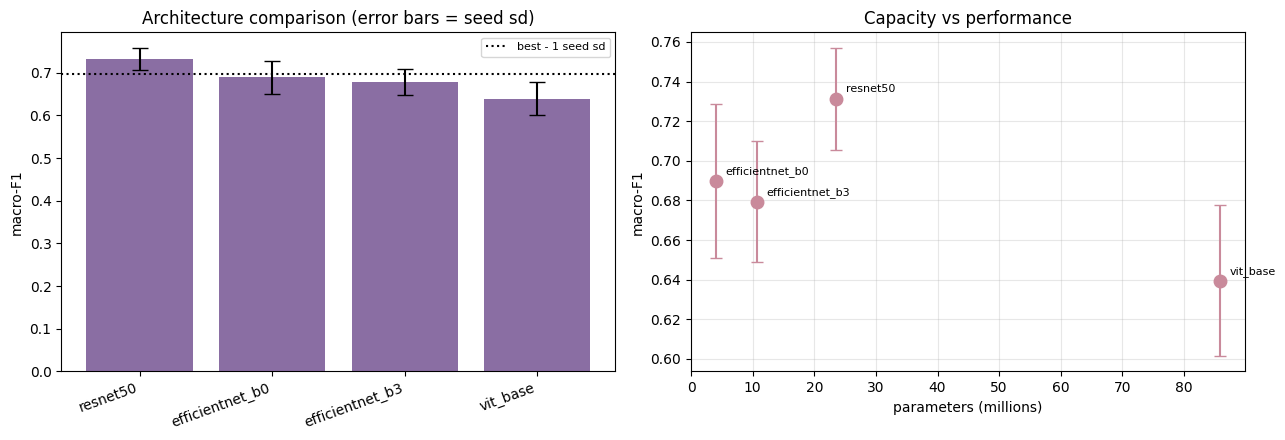


Saved: arch_comparison_raw.csv, arch_comparison_summary.csv, arch_comparison.png, arch_result.json


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(agg))
axes[0].bar(x, agg.f1_mean, yerr=agg.f1_std.fillna(0), capsize=6,
            color="#8a6ea3")
axes[0].axhline(agg.f1_mean.max() - pooled_sd, color="k", ls=":",
                label="best - 1 seed sd")
axes[0].set_xticks(x); axes[0].set_xticklabels(agg.arch, rotation=20, ha="right")
axes[0].set_ylabel("macro-F1"); axes[0].legend(fontsize=8)
axes[0].set_title("Architecture comparison (error bars = seed sd)")

axes[1].errorbar(agg.params_m, agg.f1_mean, yerr=agg.f1_std.fillna(0),
                 fmt="o", capsize=4, markersize=9, color="#c98a9b")
for r in agg.itertuples():
    axes[1].annotate(r.arch, (r.params_m, r.f1_mean),
                     textcoords="offset points", xytext=(7, 5), fontsize=8)
axes[1].set_xlabel("parameters (millions)"); axes[1].set_ylabel("macro-F1")
axes[1].set_title("Capacity vs performance")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK, "arch_comparison.png"), dpi=120)
plt.show()

with open(os.path.join(WORK, "arch_result.json"), "w") as fh:
    json.dump(dict(best=str(best.arch), best_f1=float(best.f1_mean),
                   pooled_seed_sd=pooled_sd,
                   spread=float(agg.f1_mean.max() - agg.f1_mean.min()),
                   resolved=bool(resolved),
                   architectures=list(ARCHITECTURES), seeds=SEEDS,
                   epochs=EPOCHS), fh, indent=2)
print("\nSaved: arch_comparison_raw.csv, arch_comparison_summary.csv, "
      "arch_comparison.png, arch_result.json")